In [ ]:
!pip install yfinance


In [2]:
!pip install arch

  Using cached arch-8.0.0-cp313-cp313-win_amd64.whl.metadata (13 kB)
Using cached arch-8.0.0-cp313-cp313-win_amd64.whl (929 kB)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import skew, kurtosis, jarque_bera
import numpy as np
from scipy.stats import chi2
from arch import arch_model

In [3]:
ticker = "XU100.IS"
start_date = "2015-01-01"
end_date = "2025-01-01"

In [4]:
data = yf.download(ticker, start=start_date, end=end_date)

data.head()

C:\Users\orcun.icen\AppData\Local\Temp\ipykernel_23452\3209511123.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,XU100.IS,XU100.IS,XU100.IS,XU100.IS,XU100.IS
Date,,,,,
2015-01-02,854.584473,857.716475,849.404507,854.474488,32803700000
2015-01-05,864.621399,867.953413,854.109492,854.948477,64458800000
2015-01-06,869.091370,869.113342,855.742442,866.504347,69832100000
2015-01-07,867.761414,876.255387,864.973464,869.246391,79194900000
2015-01-08,876.891357,879.186328,872.599388,874.044388,73176200000


In [5]:
df = pd.DataFrame()
df["Price"] = data["Close"]
df["Return"] = np.log(df["Price"] / df["Price"].shift(1))
df = df.dropna()

df.head()

,Price,Return
Date,,
2015-01-05,864.621399,0.011676
2015-01-06,869.091370,0.005157
2015-01-07,867.761414,-0.001531
2015-01-08,876.891357,0.010466
2015-01-09,876.479370,-0.000470


Gözlem sayısı: 2501
count    2501.000000
mean        0.000977
std         0.015789
min        -0.103038
25%        -0.007146
50%         0.001370
75%         0.009638
max         0.094234
Name: Return, dtype: float64


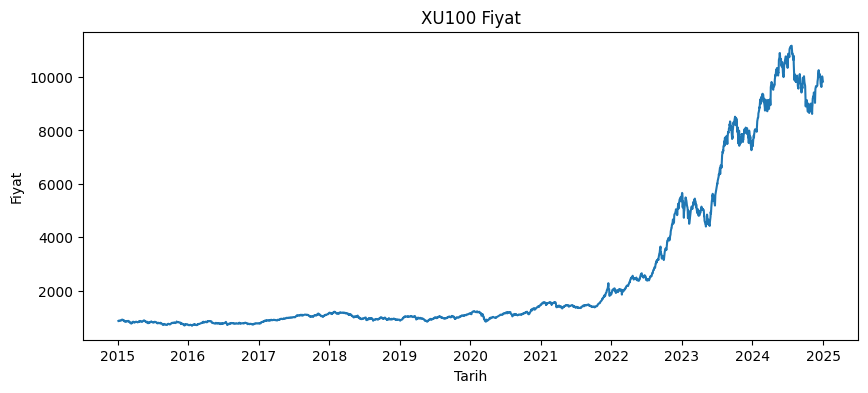

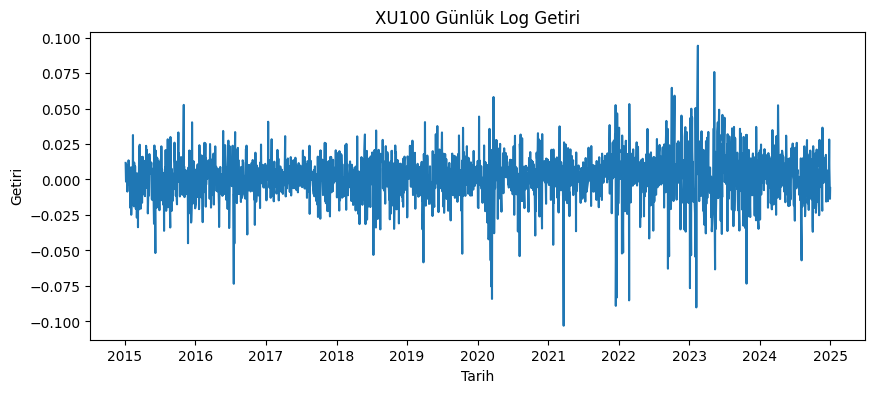

In [6]:
print("Gözlem sayısı:", len(df))
print(df["Return"].describe())
plt.figure(figsize=(10,4))
plt.plot(df["Price"])
plt.title("XU100 Fiyat")
plt.xlabel("Tarih")
plt.ylabel("Fiyat")
plt.show()
plt.figure(figsize=(10,4))
plt.plot(df["Return"])
plt.title("XU100 Günlük Log Getiri")
plt.xlabel("Tarih")
plt.ylabel("Getiri")
plt.show()


In [7]:
conf_level = 0.99
alpha = 1 - conf_level
sorted_returns = df["Return"].sort_values()

var_hist = sorted_returns.quantile(alpha)
es_hist = sorted_returns[sorted_returns <= var_hist].mean()

print(f"%99 Tarihsel VaR (getiri): {var_hist:.4f}")
print(f"%99 Tarihsel ES  (getiri): {es_hist:.4f}")
position = 10_000_000
var_tl = -var_hist * position
es_tl  = -es_hist * position

print(f"\nPozisyon: {position:,.0f} TL")
print(f"%99 Günlük VaR (TL): {var_tl:,.0f}")
print(f"%99 Günlük ES  (TL): {es_tl:,.0f}")

%99 Tarihsel VaR (getiri): -0.0460
%99 Tarihsel ES  (getiri): -0.0655

Pozisyon: 10,000,000 TL
%99 Günlük VaR (TL): 460,272
%99 Günlük ES  (TL): 654,795


In [8]:
df["VaR_breach"] = df["Return"] < var_hist  # True = ihlal
breaches = df["VaR_breach"].sum()
total_days = len(df)

print(f"Toplam gün sayısı: {total_days}")
print(f"Gerçekleşen ihlal sayısı: {breaches}")
print(f"İhlal oranı: {breaches/total_days:.4f}")

Toplam gün sayısı: 2501
Gerçekleşen ihlal sayısı: 26
İhlal oranı: 0.0104


#Skewness, kurtosis,JBera 

In [9]:
skewness = skew(df["Return"])

In [10]:
kurt = kurtosis(df["Return"], fisher=True)

In [11]:
jb_stat, jb_pvalue = jarque_bera(df["Return"])

In [12]:
print(f"Skewness: {skewness:.4f}")
print(f"Excess Kurtosis: {kurt:.4f}")
print(f"Jarque-Bera statistic: {jb_stat:.2f}")
print(f"Jarque-Bera p-value: {jb_pvalue:.6f}")

Skewness: -0.6124
Excess Kurtosis: 4.6843
Jarque-Bera statistic: 2442.96
Jarque-Bera p-value: 0.000000


The results exhibits statistically significant negative skewness and excess kurtosis, with rejecting Jarque-Bera test.HVar achieves correct unconditional coverage, however ES-Var gap highlight major tail risk, indicating that parametric normal Var is unsuitable for this market.

H0:normal dağılım
H1: normal dağılım değil   0.000<0.05 ho red. kayıplar kazançlara ağır basıyor skewness değeri yüksek. Kurtosis değerine göre fat-tail var.

In [13]:
alpha = 0.01
T = len(df)
x = breaches
pi_hat = x / T
LR_uc = -2 * (
    np.log((1 - alpha)**(T - x) * alpha**x) -
    np.log((1 - pi_hat)**(T - x) * pi_hat**x)
)

p_value_uc = 1 - chi2.cdf(LR_uc, df=1)

print(f"Kupiec LR statistic: {LR_uc:.4f}")
print(f"Kupiec p-value: {p_value_uc:.4f}")

Kupiec LR statistic: 0.0391
Kupiec p-value: 0.8433


In [14]:
# 0.8433>0.05 ho reddedilemez. Modelimiz doğru çalışmaktadır.Gerçekleşen kayıplar beklenen kayıpları desteklemektedir.

In [15]:
breach = df["VaR_breach"].astype(int)
n00 = n01 = n10 = n11 = 0
for i in range(1, len(breach)):
    if breach[i-1] == 0 and breach[i] == 0: n00 += 1
    if breach[i-1] == 0 and breach[i] == 1: n01 += 1
    if breach[i-1] == 1 and breach[i] == 0: n10 += 1
    if breach[i-1] == 1 and breach[i] == 1: n11 += 1

pi01 = n01 / (n00 + n01)
pi11 = n11 / (n10 + n11)
pi   = (n01 + n11) / (n00 + n01 + n10 + n11)

LR_ind = -2 * (
    np.log((1-pi)**(n00+n10) * pi**(n01+n11)) -
    np.log((1-pi01)**n00 * pi01**n01 * (1-pi11)**n10 * pi11**n11)
)

p_value_ind = 1 - chi2.cdf(LR_ind, df=1)

print(f"Christoffersen LR statistic: {LR_ind:.4f}")
print(f"Independence p-value: {p_value_ind:.4f}")


Christoffersen LR statistic: 1.1985
Independence p-value: 0.2736


C:\Users\orcun.icen\AppData\Local\Temp\ipykernel_23452\2166859235.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if breach[i-1] == 0 and breach[i] == 0: n00 += 1
C:\Users\orcun.icen\AppData\Local\Temp\ipykernel_23452\2166859235.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if breach[i-1] == 0 and breach[i] == 1: n01 += 1
C:\Users\orcun.icen\AppData\Local\Temp\ipykernel_23452\2166859235.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `s

In [16]:
# Christoffersen testine göre 0.27>0.05 Ho reddedilemez. Var modeli doğru çalışmaktadır. Kümelenme yoktur.

In [17]:
from scipy.stats import t

mu = df["Return"].mean()
sigma = df["Return"].std()
nu = 6
t_quantile = t.ppf(0.01, df=nu)

var_t = mu + sigma * t_quantile * np.sqrt((nu-2)/nu)

print(f"%99 Student-t VaR (getiri): {var_t:.4f}")
print(f"%99 Student-t VaR (TL): {-var_t * 10_000_000:,.0f}")

%99 Student-t VaR (getiri): -0.0395
%99 Student-t VaR (TL): 395,368


Fat-Tail olduğundan dolayı ve asimetrik olduğu için Kuyruk riskleri modellemesi ihtiyacı doğmuş ve Studentt Var hesaplanmıştır.

In [18]:
returns = df["Return"] * 100
model = arch_model(
    returns,
    vol="Garch",
    p=1, q=1,
    dist="t",
    mean="Constant"
)

res = model.fit(disp="off")

print(res.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                       Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -4439.41
Distribution:      Standardized Student's t   AIC:                           8888.83
Method:                  Maximum Likelihood   BIC:                           8917.95
                                              No. Observations:                 2501
Date:                      Tue, Dec 23 2025   Df Residuals:                     2500
Time:                              17:11:56   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

alfa+beta=0.97 1 e çok yakın yüksek volatilite kalıcığı  alfa anlamlı şoklar varyansa dayalı, 

The XU100 index exhibits significant non-normality, characterized by negative skewness and excess kurtosis. The Jarque–Bera test strongly rejects normality, indicating pronounced tail risk.

Historical VaR achieves correct unconditional and conditional coverage, as confirmed by Kupiec and Christoffersen tests. However, the large ES–VaR gap highlights substantial downside tail risk.

To address volatility clustering and fat tails, a GARCH(1,1) model with Student-t innovations is estimated. The results show highly persistent conditional volatility (α+β≈0.97) and statistically significant heavy-tailed behavior.

Overall, static normal VaR is unsuitable for this market, while dynamic GARCH-based risk measures provide a more realistic representation of downside risk.